# TASK 5. EMBEDDING FUNDAMENTALS

## Objective

This task demonstrates how text embeddings convert textual information into numerical vectors and how semantically similar documents are grouped together.

### Goals:
- Generate embeddings for 50+ documents.
- Understand semantic similarity.
- Reduce high-dimensional embeddings using t-SNE.
- Visualize document clusters.
- Analyze relationships between different topics.

Notebook Structure


-TASK 5. EMBEDDING FUNDAMENTALS

1. Objective
2. Install Libraries
3. Create 50+ Documents
4. Generate Embeddings
5. Apply t-SNE
6. Visualize Results
7. Analysis
8. Conclusion

Step 1: Install Libraries

In [12]:
!pip install openai pandas matplotlib scikit-learn python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 2: Import Libraries

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
from openai import OpenAI

from sklearn.manifold import TSNE

Step 3: Load API

In [2]:
# Let's install and import OpenAI Package
!pip install --upgrade openai
from openai import OpenAI  

# Let's import os Python module, which stands for "Operating System"
# The os module lets you interact with your computer’s operating system
import os

# This will be used to load the API key from the .env file
from dotenv import load_dotenv
load_dotenv()

# Get the OpenAI API keys from environment variables
openai_api_key = os.getenv("API_KEY")

# Let's configure the OpenAI Client using our key
openai_client = OpenAI(api_key = openai_api_key)
print("\nOpenAI client successfully configured.")

# Let's view the first few characters in the key
print(openai_api_key[:3])


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



OpenAI client successfully configured.
sk-


Step 4: Create Document Corpus

A corpus of 55 documents is created across multiple domains including:

- Artificial Intelligence
- Programming
- Databases
- Education
- Healthcare
- Finance
- Transportation
- Sports
- Business
- Environment
- Technology

This diverse dataset helps demonstrate semantic clustering.

In [3]:
documents = [

    # Artificial Intelligence & Data Science
    "Artificial Intelligence enables machines to perform tasks that normally require human intelligence.",
    "Machine Learning algorithms learn patterns from historical data to make predictions.",
    "Deep Learning uses multi-layer neural networks for complex pattern recognition.",
    "Natural Language Processing enables computers to understand human language.",
    "Computer Vision allows machines to interpret and analyze visual information.",
    "Large Language Models generate human-like text using transformer architectures.",
    "Prompt engineering improves the quality of AI-generated responses.",
    "Retrieval-Augmented Generation combines external knowledge with language models.",
    "Embeddings convert textual information into numerical vector representations.",
    "Data Science integrates statistics, programming, and machine learning techniques.",

    # Programming & Development
    "Python is widely used for data science and artificial intelligence applications.",
    "Object-oriented programming improves code reusability and maintainability.",
    "APIs enable communication between different software applications.",
    "Git is a distributed version control system used in software development.",
    "Docker simplifies application deployment through containerization.",

    # Databases & Cloud
    "SQL databases organize structured information using tables and relationships.",
    "MongoDB is a NoSQL database designed for flexible document storage.",
    "Cloud computing provides scalable computing resources over the internet.",
    "Amazon Web Services offers various cloud-based solutions.",
    "Cybersecurity protects digital systems from unauthorized access and attacks.",

    # Education
    "Online learning platforms provide flexible access to educational resources.",
    "Project-based learning enhances practical knowledge and problem-solving skills.",
    "Assignments help students reinforce theoretical concepts.",
    "Examinations evaluate a student's understanding of academic subjects.",
    "Data science education combines mathematics, programming, and analytics.",

    # Healthcare
    "Artificial Intelligence assists doctors in disease diagnosis and medical imaging.",
    "Machine learning models can predict potential health risks.",
    "Electronic health records improve healthcare management systems.",
    "Medical imaging technologies support accurate diagnosis.",
    "Telemedicine enables remote consultation between doctors and patients.",

    # Finance
    "Financial analytics helps organizations make data-driven decisions.",
    "Fraud detection systems use machine learning algorithms.",
    "Stock market analysis relies on historical and real-time data.",
    "Digital payment systems have transformed financial transactions.",
    "Risk management is essential in financial institutions.",

    # Transportation
    "Electric vehicles reduce carbon emissions and improve sustainability.",
    "Autonomous vehicles use sensors and artificial intelligence.",
    "Railway transportation efficiently connects major cities.",
    "Air transportation enables rapid international travel.",
    "Smart traffic management systems improve urban mobility.",

    # Sports
    "Cricket is one of the most popular sports in India.",
    "Football analytics uses data to improve team performance.",
    "Athlete performance can be monitored using wearable devices.",
    "Sports analytics helps coaches make strategic decisions.",
    "Olympic events promote international sporting competition.",

    # Business
    "Business intelligence tools support organizational decision-making.",
    "Customer relationship management improves customer satisfaction.",
    "Data analytics helps companies understand market trends.",
    "Digital marketing uses online platforms to reach customers.",
    "E-commerce platforms have transformed retail businesses.",

    # Environment
    "Renewable energy sources help reduce environmental pollution.",
    "Climate change impacts ecosystems and biodiversity.",
    "Solar energy is an important source of sustainable power.",
    "Waste management supports environmental sustainability.",
    "Green technologies promote eco-friendly development.",

    # General Technology
    "Internet of Things devices collect and exchange data automatically.",
    "Blockchain technology provides secure decentralized transactions.",
    "5G networks enable faster communication services.",
    "Quantum computing has the potential to solve complex problems.",
    "Augmented reality enhances real-world experiences using digital content."
]

## Step 5: Generate Text Embeddings

The OpenAI embedding model converts each document into a high-dimensional numerical vector that captures semantic meaning.

In [5]:
embeddings = []

for doc in documents:
    response = openai_client.embeddings.create(
        model="text-embedding-3-small",
        input=doc
    )

    embeddings.append(response.data[0].embedding)

Step 6: Apply t-SNE Dimensionality Reduction

- Text embeddings contain hundreds of dimensions.
- t-SNE reduces these dimensions into two dimensions so that the relationships between documents can be visualized.

In [8]:
import numpy as np

embedding_array = np.array(embeddings)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=10
)

reduced = tsne.fit_transform(embedding_array)

Step 7: Visualize Embeddings

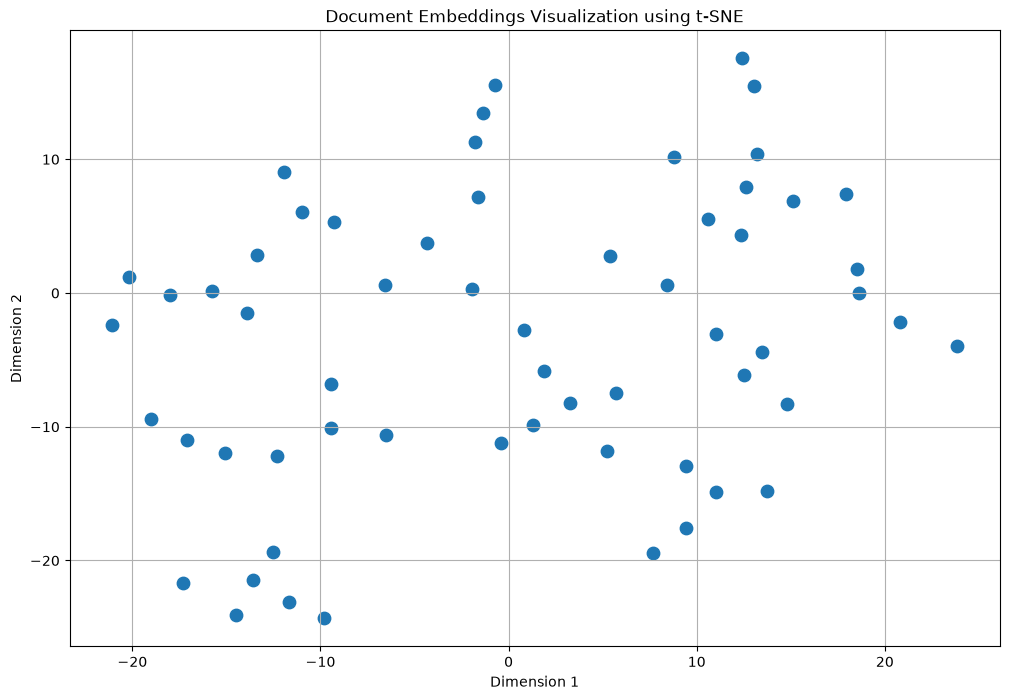

In [9]:
plt.figure(figsize=(12,8))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    s=80
)

plt.title("Document Embeddings Visualization using t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.grid(True)

plt.show()

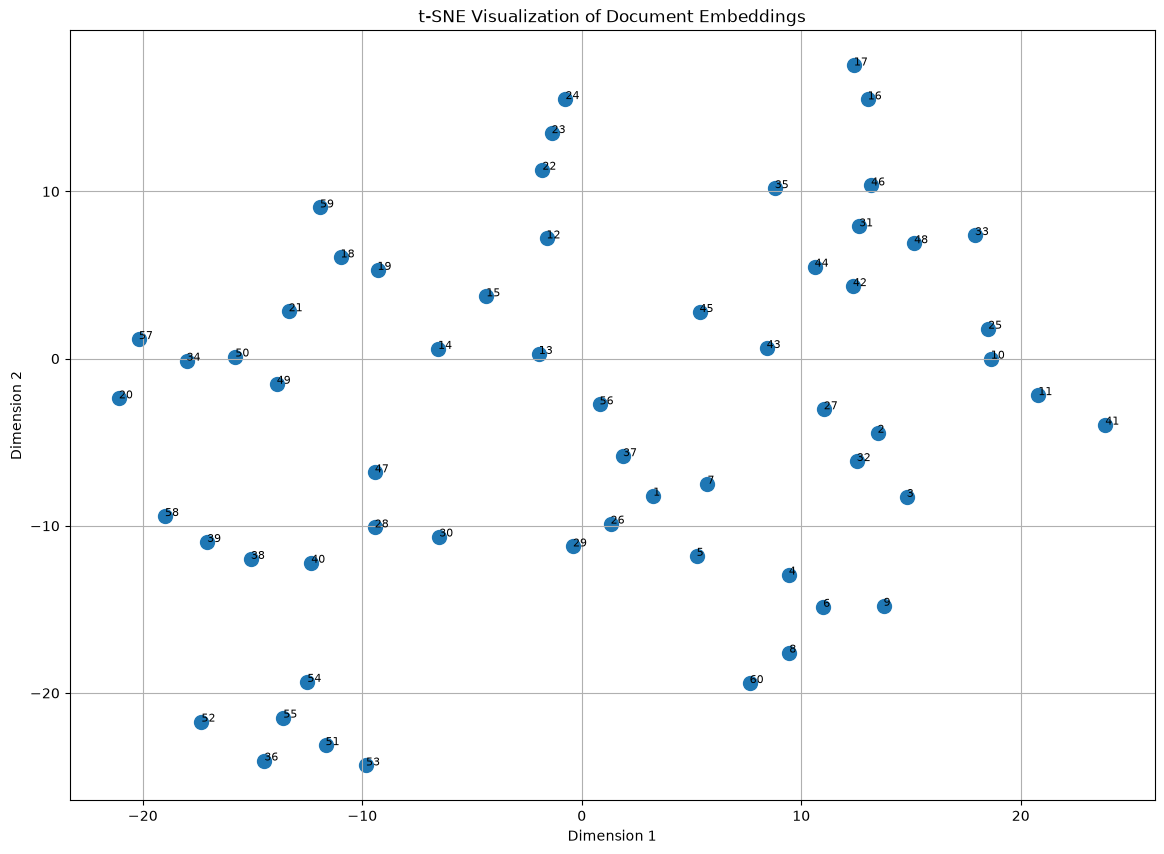

In [10]:
plt.figure(figsize=(14,10))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    s=100
)

for i in range(len(documents)):
    plt.annotate(
        str(i+1),
        (reduced[i,0], reduced[i,1]),
        fontsize=8
    )

plt.title("t-SNE Visualization of Document Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.grid(True)
plt.show()

## Analysis

The t-SNE visualization shows that semantically similar documents tend to appear closer together.

- Artificial Intelligence and Data Science documents form one cluster.
- Business and Finance documents appear in nearby regions.
- Healthcare and Education documents show semantic similarity.
- Technology-related documents create separate groups.

This demonstrates that embeddings capture the meaning of text rather than just individual words.

## Conclusion

This experiment demonstrated how text embeddings convert textual information into numerical vector representations.

The t-SNE algorithm successfully reduced high-dimensional embeddings into two dimensions, making semantic relationships easier to visualize.

The resulting clusters indicate that similar topics appear closer together in the embedding space.

Applications of embeddings include:

- Semantic Search
- Recommendation Systems
- Document Clustering
- Chatbots
- Retrieval-Augmented Generation (RAG)
- Information Retrieval Systems

Embedding models are a fundamental component of modern AI applications and large language model systems.